# Diabetes Readmission — Handling the Class Imbalance

The `U1-7_Imbalance-*` notebooks developed four responses to class imbalance on small synthetic
clouds where the effect of each could be seen directly. This notebook applies them to the real
problem: an 11% positive rate on 25,000 patient encounters, hundreds of features, and a genuine
clinical cost to missing a readmission.

Two approaches are put head to head — **searched class weights** and **SMOTE oversampling** — both
scored by cross-validation.

## Learning objectives

- Establish an unweighted baseline and read its minority-class failure
- Search class weights with `GridSearchCV` over Dirichlet-sampled candidates
- Compare a searched weight against the inverse-frequency default
- Apply SMOTE inside cross-validation without leaking across folds
- Judge every variant on minority-class F1

## Background

This notebook assumes the preprocessed table from `U1_Diabetes-2_Preprocess`, and the four
imbalance techniques from Unit 1 section 7: stratified folds
(`U1-7_Imbalance-1_StratifiedKFold`), resampling (`-2_Resampling`), SMOTE (`-3_SMOTE`), and class
weights searched over a Dirichlet sample (`-4_ClassWeights`, `-5_Dirichlet`). Each is used here as
established rather than re-derived.

**Prerequisites:** `U1_Diabetes-3_Classification` (baseline and metrics),
`U1-7_Imbalance-3_SMOTE`, `U1-7_Imbalance-5_Dirichlet`

**Dataset:** `diabetes_hospital_preprocessed.csv` — subsampled to 25,000 encounters, ~11% positive.

**References:** https://imbalanced-learn.org/stable/common_pitfalls.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from tqdm import tqdm

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Load the preprocessed data

`U1_Diabetes-2_Preprocess` already dropped the leakage columns and dummy-encoded every
categorical, saving the result to `diabetes_hospital_preprocessed.csv`. We load that and go
straight to modeling.

### 1.1 Subsample

The full dataset is ~102k encounters — fine for production, slow for classroom experimentation. We
take a **seeded, stratified** subsample of 25,000: stratified so the ~11% positive rate is
preserved exactly, seeded so every notebook in this spine sees the same 25,000 patients and their
results are comparable.

In [2]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'

# Load the fully preprocessed dataset saved by notebook 2.
df = pd.read_csv(data_folder + 'Diabetes/diabetes_hospital_preprocessed.csv')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 42 columns):
 #   Column                                      Non-Null Count   Dtype
---  ------                                      --------------   -----
 0   age                                         101766 non-null  int64
 1   time_in_hospital                            101766 non-null  int64
 2   num_lab_procedures                          101766 non-null  int64
 3   num_procedures                              101766 non-null  int64
 4   num_medications                             101766 non-null  int64
 5   number_diagnoses                            101766 non-null  int64
 6   readmit_30_days                             101766 non-null  int64
 7   race_AfricanAmerican                        101766 non-null  int64
 8   race_Asian                                  101766 non-null  int64
 9   race_Hispanic                               101766 non-null  int64
 10  race_Other          

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,readmit_30_days,race_AfricanAmerican,race_Asian,race_Hispanic,race_Other,race_Unknown,gender_Male,gender_Unknown/Invalid,discharge_disposition_id_Other,admission_source_id_Other,admission_source_id_Referral,medical_specialty_Cardiology,medical_specialty_Emergency/Trauma,medical_specialty_Family/GeneralPractice,medical_specialty_InternalMedicine,medical_specialty_Other,primary_diagnosis_'Genitourinary Issues',primary_diagnosis_'Musculoskeletal Issues',primary_diagnosis_'Respiratory Issues',primary_diagnosis_Diabetes,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_Norm,insulin_Down,insulin_Steady,insulin_Up,change_Ch,diabetesMed_No,medicare_True,medicaid_True,had_emergency_True,had_inpatient_days_True,had_outpatient_days_True
0,0,1,41,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,3,59,0,18,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
2,0,2,11,5,13,6,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,1,2,44,1,16,7,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
4,1,1,51,0,8,5,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0


The full dataset has ~102k encounters — great for production, slow for classroom experimentation. We work with a seeded **stratified** subsample of 25,000 rows (~2,800 positives), which preserves the class ratio.

In [3]:
from sklearn.model_selection import train_test_split

df, _ = train_test_split(
    df,
    train_size=25_000,
    stratify=df['readmit_30_days'],
    random_state=42
)
df = df.reset_index(drop=True)

print(df.shape)
print(f"positive rate: {df['readmit_30_days'].mean():.1%}")

(25000, 42)
positive rate: 11.2%


## 2. Prepare the data for modeling

In [4]:
df.sample(5)

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,readmit_30_days,race_AfricanAmerican,race_Asian,race_Hispanic,race_Other,race_Unknown,gender_Male,gender_Unknown/Invalid,discharge_disposition_id_Other,admission_source_id_Other,admission_source_id_Referral,medical_specialty_Cardiology,medical_specialty_Emergency/Trauma,medical_specialty_Family/GeneralPractice,medical_specialty_InternalMedicine,medical_specialty_Other,primary_diagnosis_'Genitourinary Issues',primary_diagnosis_'Musculoskeletal Issues',primary_diagnosis_'Respiratory Issues',primary_diagnosis_Diabetes,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_Norm,insulin_Down,insulin_Steady,insulin_Up,change_Ch,diabetesMed_No,medicare_True,medicaid_True,had_emergency_True,had_inpatient_days_True,had_outpatient_days_True
17395,2,3,56,3,25,6,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
22564,2,2,34,2,20,3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0
5394,2,1,39,2,10,4,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0
20726,2,3,40,3,21,6,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
19729,1,8,65,3,24,9,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0


In [5]:
label = 'readmit_30_days'
vc = df[label].value_counts()
vc

readmit_30_days
0    22210
1     2790
Name: count, dtype: int64

In [6]:
# Binary target: already 0/1, so no rare-class filtering or label encoding is needed.
X_raw = df.drop(columns=[label])
y = df[label].copy()

y.value_counts()

readmit_30_days
0    22210
1     2790
Name: count, dtype: int64

### 2.1 Scale the features

Everything loaded from notebook 2 is numeric — ordinal age plus dummy columns — so the whole
matrix is scaled. Tree models are indifferent to feature scale, but logistic regression, KNN, and
neural networks are not, and we are about to compare all of them on equal footing.

In [7]:
from sklearn.preprocessing import StandardScaler

# The data loaded from notebook 2 is already dummy-encoded, so every feature
# column is numeric. We scale the entire feature matrix to zero mean, unit variance.
std_scaler = StandardScaler()

X = pd.DataFrame(
    std_scaler.fit_transform(X_raw),
    columns=X_raw.columns,
    index=X_raw.index
)

X.head()

,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,race_AfricanAmerican,race_Asian,race_Hispanic,race_Other,race_Unknown,gender_Male,gender_Unknown/Invalid,discharge_disposition_id_Other,admission_source_id_Other,admission_source_id_Referral,medical_specialty_Cardiology,medical_specialty_Emergency/Trauma,medical_specialty_Family/GeneralPractice,medical_specialty_InternalMedicine,medical_specialty_Other,primary_diagnosis_'Genitourinary Issues',primary_diagnosis_'Musculoskeletal Issues',primary_diagnosis_'Respiratory Issues',primary_diagnosis_Diabetes,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_Norm,insulin_Down,insulin_Steady,insulin_Up,change_Ch,diabetesMed_No,medicare_True,medicaid_True,had_emergency_True,had_inpatient_days_True,had_outpatient_days_True
0,0.667206,2.562889,2.339641,-0.195398,1.714086,0.818711,-0.483441,-0.078471,-0.148301,-0.123404,-0.149704,1.080077,-0.008945,1.206164,-0.390375,-0.662582,-0.240226,3.499792,-0.281285,-0.407619,-0.446075,-0.229222,-0.228836,-0.406083,3.261707,-0.122229,-0.112782,-0.162088,-0.199292,3.406928,-0.229512,2.673196,-0.658397,-0.354428,1.070564,-0.546165,1.469204,-0.193136,2.821449,-0.702064,-0.443688
1,0.667206,-1.137830,0.409234,-0.783592,-0.982776,-0.734427,-0.483441,-0.078471,-0.148301,8.103497,-0.149704,1.080077,-0.008945,-0.829075,-0.390375,-0.662582,-0.240226,-0.285731,-0.281285,2.453269,-0.446075,-0.229222,-0.228836,2.462548,-0.306588,-0.122229,-0.112782,6.169481,-0.199292,-0.293520,-0.229512,-0.374084,-0.658397,-0.354428,-0.934087,1.830947,-0.680641,-0.193136,-0.354428,-0.702064,-0.443688
2,0.667206,-0.801401,0.714035,-0.783592,-0.492437,-1.252140,2.068506,-0.078471,-0.148301,-0.123404,-0.149704,-0.925860,-0.008945,-0.829075,-0.390375,-0.662582,-0.240226,-0.285731,-0.281285,-0.407619,-0.446075,-0.229222,-0.228836,-0.406083,-0.306588,-0.122229,-0.112782,-0.162088,-0.199292,-0.293520,-0.229512,2.673196,-0.658397,-0.354428,1.070564,-0.546165,-0.680641,-0.193136,-0.354428,1.424372,2.253834
3,0.667206,1.553602,0.510834,-0.195398,-0.124683,-1.252140,-0.483441,-0.078471,-0.148301,-0.123404,-0.149704,-0.925860,-0.008945,1.206164,-0.390375,-0.662582,-0.240226,-0.285731,-0.281285,2.453269,-0.446075,-0.229222,-0.228836,-0.406083,-0.306588,-0.122229,8.866670,-0.162088,-0.199292,-0.293520,-0.229512,-0.374084,-0.658397,-0.354428,-0.934087,1.830947,-0.680641,-0.193136,-0.354428,1.424372,-0.443688
4,0.667206,-0.801401,-0.911571,-0.783592,-0.615022,-0.734427,-0.483441,-0.078471,-0.148301,-0.123404,-0.149704,-0.925860,-0.008945,-0.829075,-0.390375,1.509248,-0.240226,-0.285731,-0.281285,-0.407619,2.241773,-0.229222,-0.228836,2.462548,-0.306588,-0.122229,-0.112782,-0.162088,-0.199292,-0.293520,-0.229512,-0.374084,1.518841,-0.354428,-0.934087,-0.546165,-0.680641,-0.193136,2.821449,-0.702064,-0.443688


## 3. The unweighted baseline

A plain `RandomForestClassifier`, no weighting, no resampling — the thing to beat.

Read the confusion matrix rather than the accuracy. At an 11% positive rate an unweighted model
typically achieves high accuracy alongside poor recall on the readmitted class: it has learned that
predicting "not readmitted" is usually right. For triage that is precisely the wrong trade, since
the whole purpose is to find the patients at risk.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.00      0.00      0.00       558

    accuracy                           0.89      5000
   macro avg       0.44      0.50      0.47      5000
weighted avg       0.79      0.89      0.84      5000



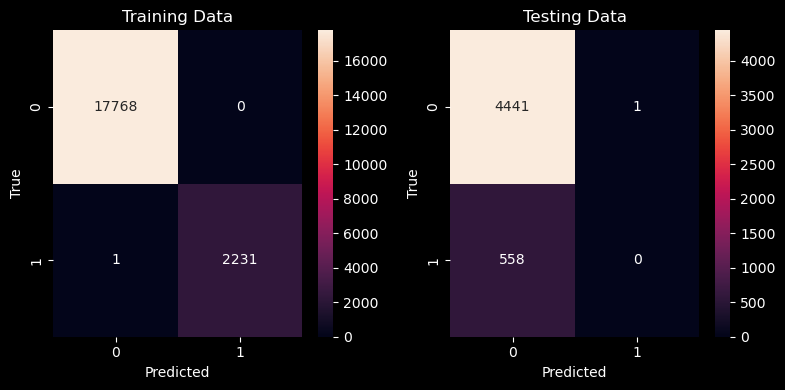

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(classification_report(y_test, y_test_pred))

conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(int)
conf_matrix_test = confusion_matrix(y_test, y_test_pred).astype(int)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Training Data")

sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Testing Data")

plt.tight_layout()
plt.show()

## 4. Searched class weights

With a **binary** target the Dirichlet distribution over two weights reduces to a Beta distribution — the mechanics below are unchanged from the multiclass version in `U1-7_Imbalance-5_Dirichlet`.

The mechanics are those of `U1-7_Imbalance-5_Dirichlet`, simplified by the binary target: over two
classes the Dirichlet reduces to a Beta distribution, so each draw is really a single weight $w$
with the other being $1-w$. The candidates go to `GridSearchCV` as a list, turning it into a random
search over the weight range, scored by stratified cross-validation.

In [10]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define StratifiedKFold for balanced class distribution
skf = StratifiedKFold(n_splits=5, shuffle=True)

vc = y.value_counts().sort_index()
vc = 1 / vc
balanced = vc / vc.sum()

alpha = 0.1

# Define the parameter grid
dirichlet_samples = [dict(enumerate(alpha*weights + (1-alpha)*balanced)) for weights in np.random.dirichlet(alpha=np.ones(df[label].nunique()), size=50)]

param_grid = {'class_weight': dirichlet_samples}

model = RandomForestClassifier(n_jobs=-1)

# Perform GridSearchCV with StratifiedKFold
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=skf,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

grid_search.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


{'class_weight': {0: 0.11390488239244653, 1: 0.8860951176075536}}

In [11]:
best_params = list(grid_search.best_params_['class_weight'].values())
best_params

[0.11390488239244653, 0.8860951176075536]

### 4.1 Against the inverse-frequency default

The cell below computes the inverse-frequency weights — the same quantity `class_weight='balanced'`
uses — as a reference point for what the search found.

The comparison is the interesting part. `'balanced'` answers "make the classes count equally", which
is a reasonable default and not an optimum for any specific goal. A search scored on macro F1
answers a different question and generally lands somewhere else. Neither is wrong; they optimize
different objectives, and `U1-7_Imbalance-4_ClassWeights` shows how to make that objective explicit
with a reward matrix when the costs are actually known.

In [12]:
vc = y.value_counts().sort_index()
vc = 1 / vc
vc = vc / vc.sum()
vc

readmit_30_days
0    0.1116
1    0.8884
Name: count, dtype: float64

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      4442
           1       0.00      0.00      0.00       558

    accuracy                           0.89      5000
   macro avg       0.44      0.50      0.47      5000
weighted avg       0.79      0.89      0.84      5000



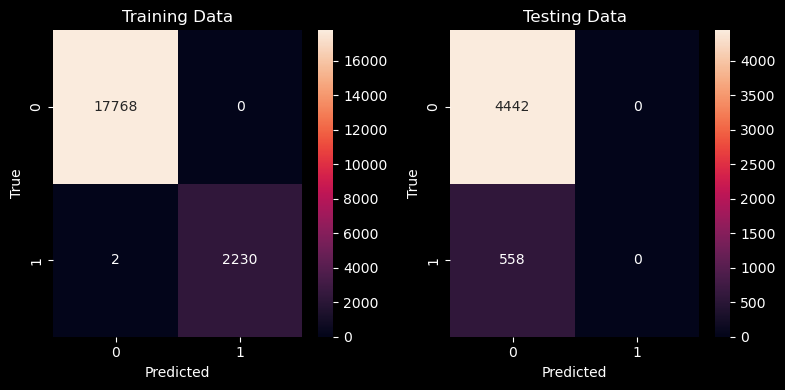

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

#########################
### CHECK PERFORMANCE ###
#########################
model = grid_search.best_estimator_

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(classification_report(y_test, y_test_pred))

conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(int)
conf_matrix_test = confusion_matrix(y_test, y_test_pred).astype(int)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Training Data")

sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Testing Data")

plt.tight_layout()
plt.show()

## 5. SMOTE oversampling

The alternative approach: leave the loss alone and rebalance the data, synthesizing new minority
patients along segments between existing ones as developed in `U1-7_Imbalance-3_SMOTE`.

**The critical detail is where SMOTE is applied.** It runs *inside* the cross-validation loop, on
each fold's training portion only. Resampling before the split would place synthetic points derived
from validation patients into the training set — the validation fold would then be scored on data it
helped create, and the estimate would be optimistic. This is the single most common way SMOTE is
misused, which is why `imbalanced-learn` ships a `Pipeline` that enforces the ordering.

In [14]:
from sklearn.metrics import f1_score, classification_report
from imblearn.over_sampling import SMOTE

skf = StratifiedKFold(n_splits=5, shuffle=True)

# Initialize results container
f1_scores = []

# Loop through the folds
for train_index, test_index in skf.split(X, y):
    # 1. Split the data
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
    
    # 2. Apply imblearn ONLY to the training fold
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train_fold, y_train_fold)
    
    # 3. Fit the model on resampled training data
    model = RandomForestClassifier(n_jobs=-1)
    model.fit(X_resampled, y_resampled)
    
    # 4. Predict and evaluate on the untouched test fold
    y_pred = model.predict(X_test_fold)
    score = f1_score(y_test_fold, y_pred, average='macro')
    f1_scores.append(score)

# Final performance summary
print(f"Mean Macro F1: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")

Mean Macro F1: 0.4833 (+/- 0.0039)


## 6. Review

- **An unweighted model on an 11% positive rate has good accuracy and poor minority recall** — the
  wrong trade for triage.
- **Class weights and SMOTE attack the same problem from opposite directions**: one reweights the
  loss and leaves the data alone, the other rebalances the data and leaves the loss alone.
- **With a binary target, a Dirichlet over two weights is a Beta**, so the search reduces to one
  number.
- **`class_weight='balanced'` is a default, not an optimum.** A search scored on macro F1 will
  generally choose differently, because it optimizes a different objective.
- **SMOTE belongs inside the cross-validation loop.** Resampling before splitting leaks synthetic
  points derived from validation data into training and inflates the score.
- **Every variant is judged on minority-class F1.** That is the number the clinical question
  actually cares about.